In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

print('PyTorch version:', torch.__version__)

PyTorch version: 2.10.0+cpu


In [7]:
for cell_id, cell in get_ipython().user_ns['In'].items():
    if cell_id is not None and isinstance(cell, str) and cell.strip().startswith('import'): # A simple heuristic to skip non-code cells that might be in In
        print(f'Executing cell {cell_id}')
        get_ipython().run_cell(cell)

AttributeError: 'list' object has no attribute 'items'

In [15]:
# optimizer.step() қолданбай, параметрлерді қолмен жаңарту

w = torch.tensor([5.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

x_train = torch.linspace(-5, 5, 50).reshape(-1, 1)
y_train = 2 * x_train + 3

learning_rate = 0.01
epochs = 100

print('Бастапқы параметрлер:')
print(f'w = {w.item():.4f}, b = {b.item():.4f}')

loss_history = []

for epoch in range(epochs):
    # Forward pass
    y_pred = w * x_train + b
    loss = ((y_pred - y_train)**2).mean()
    loss_history.append(loss.item())

    # Backward pass
    loss.backward()

    # Қолмен параметрлерді жаңарту (torch.no_grad() керек!)
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # Градиенттерді нөлдеу (zero_grad() орнына)
    w.grad.zero_()
    b.grad.zero_()

print('\nҮйретуден кейін:')
print(f'w = {w.item():.4f}, b = {b.item():.4f}')
print(f'Нақты мәндер: w = 2.0, b = 3.0')

# Түсіндірмелер
print('\n' + '='*50)
print('PyTorch autograd қалай көмектеседі?')
print('autograd градиенттерді автоматты түрде есептейді (backward()).',
      'Әйтпесе туындыларды қолмен есептеу керек еді.')

print('\nҚателік жібермеу үшін неге torch.no_grad() керек?')
print('torch.no_grad() параметрлерді жаңарту кезінде градиенттердің',
      'есептелуін болдырмайды. Егер оны қолданбасақ, PyTorch граф құруды',
      'жалғастырып, жадтан тыс қалуға әкелуі мүмкін.')

Бастапқы параметрлер:
w = 5.0000, b = 0.0000

Үйретуден кейін:
w = 2.0000, b = 2.6021
Нақты мәндер: w = 2.0, b = 3.0

PyTorch autograd қалай көмектеседі?
autograd градиенттерді автоматты түрде есептейді (backward()). Әйтпесе туындыларды қолмен есептеу керек еді.

Қателік жібермеу үшін неге torch.no_grad() керек?
torch.no_grad() параметрлерді жаңарту кезінде градиенттердің есептелуін болдырмайды. Егер оны қолданбасақ, PyTorch граф құруды жалғастырып, жадтан тыс қалуға әкелуі мүмкін.


MSELoss моделі:
w = 2.9660, b = -1.9081
Соңғы loss: 3.8317

L1Loss моделі:
w = 3.0343, b = -1.7985
Соңғы loss: 1.5880

Нақты мәндер: w = 3.0, b = -2.0


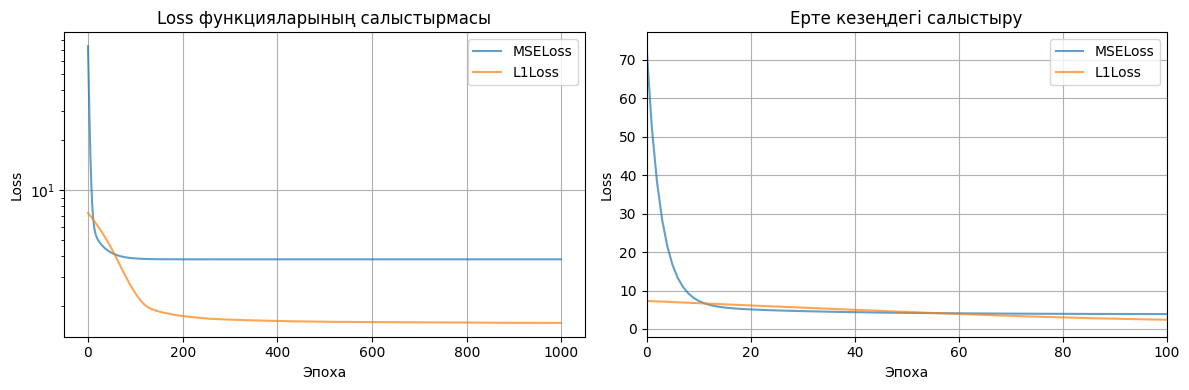


Қайсысы тезірек convergence береді?
MSELoss градиенті үлкенірек болғандықтан (квадраттық қате), алғашқы эпохаларда тезірек төмендейді. Бірақ L1Loss шуға төзімдірек және соңғы нәтижелері дәлірек болуы мүмкін.


In [14]:
# Бір деректер жиыны үшін MSELoss және L1Loss салыстыру

# Деректер дайындау (шуы бар сызықтық функция)
torch.manual_seed(42)
x_train = torch.linspace(-5, 5, 200).reshape(-1, 1)
y_train = 3 * x_train - 2 + torch.randn_like(x_train) * 2

# Екі модель құру
model_mse = nn.Linear(1, 1)
model_l1 = nn.Linear(1, 1)

# Бастапқы параметрлерді бірдей ету
with torch.no_grad():
    model_l1.weight = nn.Parameter(model_mse.weight.clone())
    model_l1.bias = nn.Parameter(model_mse.bias.clone())

criterion_mse = nn.MSELoss()
criterion_l1 = nn.L1Loss()

optimizer_mse = optim.SGD(model_mse.parameters(), lr=0.01)
optimizer_l1 = optim.SGD(model_l1.parameters(), lr=0.01)

epochs = 1000
losses_mse = []
losses_l1 = []

for epoch in range(epochs):
    # MSELoss үшін
    optimizer_mse.zero_grad()
    y_pred_mse = model_mse(x_train)
    loss_mse = criterion_mse(y_pred_mse, y_train)
    loss_mse.backward()
    optimizer_mse.step()
    losses_mse.append(loss_mse.item())

    # L1Loss үшін
    optimizer_l1.zero_grad()
    y_pred_l1 = model_l1(x_train)
    loss_l1 = criterion_l1(y_pred_l1, y_train)
    loss_l1.backward()
    optimizer_l1.step()
    losses_l1.append(loss_l1.item())

print('MSELoss моделі:')
print(f'w = {model_mse.weight.item():.4f}, b = {model_mse.bias.item():.4f}')
print(f'Соңғы loss: {losses_mse[-1]:.4f}')
print()
print('L1Loss моделі:')
print(f'w = {model_l1.weight.item():.4f}, b = {model_l1.bias.item():.4f}')
print(f'Соңғы loss: {losses_l1[-1]:.4f}')
print()
print('Нақты мәндер: w = 3.0, b = -2.0')

# Конвергенцияны салыстыру
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses_mse, label='MSELoss', alpha=0.7)
plt.plot(losses_l1, label='L1Loss', alpha=0.7)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Loss функцияларының салыстырмасы')
plt.legend()
plt.yscale('log')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(losses_mse, label='MSELoss', alpha=0.7)
plt.plot(losses_l1, label='L1Loss', alpha=0.7)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Ерте кезеңдегі салыстыру')
plt.xlim(0, 100)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print('\nҚайсысы тезірек convergence береді?')
print('MSELoss градиенті үлкенірек болғандықтан (квадраттық қате),',
      'алғашқы эпохаларда тезірек төмендейді. Бірақ L1Loss шуға төзімдірек',
      'және соңғы нәтижелері дәлірек болуы мүмкін.')

Бастапқы параметрлер:
w = -0.4119, b = 0.0419

Epoch [40/200], Loss: 1.913992
Epoch [80/200], Loss: 0.380189
Epoch [120/200], Loss: 0.075524
Epoch [160/200], Loss: 0.015003
Epoch [200/200], Loss: 0.002980

4. Үйретуден кейінгі параметрлер:
w = 5.0000, b = -2.9465
Нақты мәндер: w = 5.0, b = -3.0


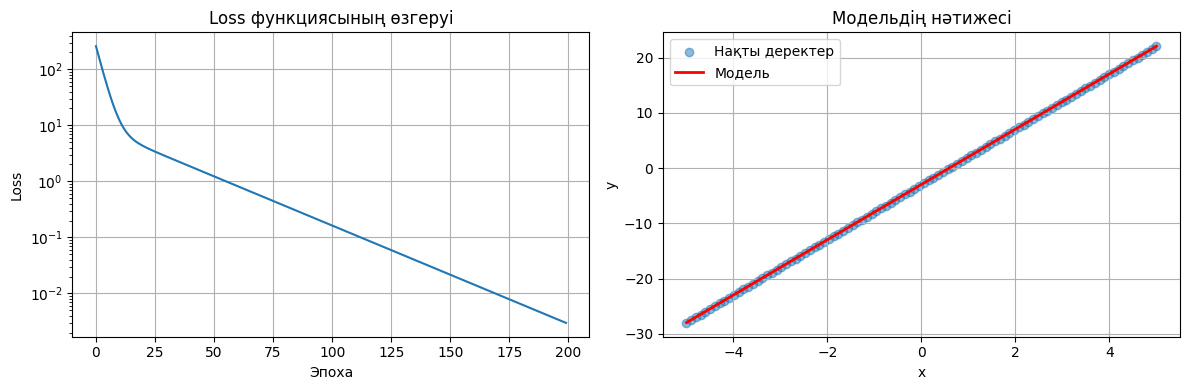

In [13]:
# 1. Бір нейрон жасау (Linear layer)
model = nn.Linear(1, 1)

# 2. Деректер дайындау: y = 5x - 3
x_train = torch.linspace(-5, 5, 100).reshape(-1, 1)
y_train = 5 * x_train - 3

# Loss және optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Бастапқы параметрлер
print('Бастапқы параметрлер:')
print(f'w = {model.weight.item():.4f}, b = {model.bias.item():.4f}')
print()

# 3. 200 эпоха бойы үйрету
losses = []

for epoch in range(200):
    # Forward pass
    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 40 == 0:
        print(f'Epoch [{epoch+1}/200], Loss: {loss.item():.6f}')

# 4. Үйретуден кейінгі параметрлер
print('\n4. Үйретуден кейінгі параметрлер:')
print(f'w = {model.weight.item():.4f}, b = {model.bias.item():.4f}')
print(f'Нақты мәндер: w = 5.0, b = -3.0')

# Нәтижені көрсету
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Loss функциясының өзгеруі')
plt.yscale('log')
plt.grid(True)

plt.subplot(1, 2, 2)
with torch.no_grad():
    y_pred_final = model(x_train)
    plt.scatter(x_train, y_train, label='Нақты деректер', alpha=0.5)
    plt.plot(x_train, y_pred_final, 'r-', label='Модель', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Модельдің нәтижесі')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

50 итерациядан кейін w = 3.999943
Соңғы loss = 0.000000
Теориялық оптимал мән: w = 4


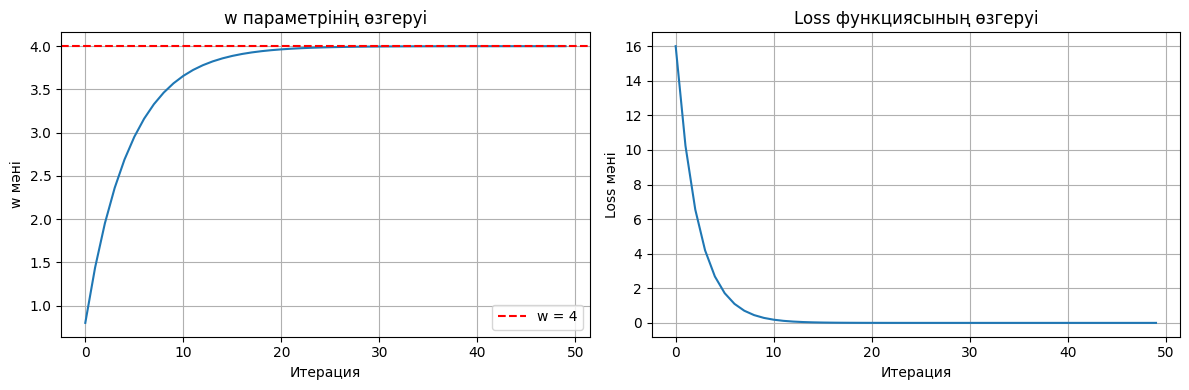

In [12]:
# L(w) = (w - 4)^2 функциясын минимизациялау

w = torch.tensor([0.0], requires_grad=True)
optimizer = optim.SGD([w], lr=0.1)

loss_history = []
w_history = []

for i in range(50):
    optimizer.zero_grad()
    loss = (w - 4)**2
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    w_history.append(w.item())

print(f'50 итерациядан кейін w = {w.item():.6f}')
print(f'Соңғы loss = {loss_history[-1]:.6f}')
print(f'Теориялық оптимал мән: w = 4')

# График
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(w_history)
plt.xlabel('Итерация')
plt.ylabel('w мәні')
plt.title('w параметрінің өзгеруі')
plt.axhline(y=4, color='r', linestyle='--', label='w = 4')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.xlabel('Итерация')
plt.ylabel('Loss мәні')
plt.title('Loss функциясының өзгеруі')
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Берілген функция: z = x^2*y + y^3

# x = 1, y = 2
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

z = x**2 * y + y**3
print('z =', z.item())

# Градиенттерді есептеу
z.backward()

dz_dx = x.grad.item()
dz_dy = y.grad.item()

print('\n1. Градиенттер:')
print('dz/dx =', dz_dx)
print('dz/dy =', dz_dy)

# 2. Қай айнымалының әсері күштірек?
print('\n2. Қай айнымалының әсері күштірек?')
if abs(dz_dx) > abs(dz_dy):
    print(f'dz/dx = {abs(dz_dx)} > dz/dy = {abs(dz_dy)} => x әсері күштірек')
elif abs(dz_dx) < abs(dz_dy):
    print(f'dz/dx = {abs(dz_dx)} < dz/dy = {abs(dz_dy)} => y әсері күштірек')
else:
    print(f'dz/dx = dz/dy = {abs(dz_dx)} => екеуінің әсері бірдей')

# Қолмен тексеру:
# ∂z/∂x = 2xy = 2*1*2 = 4
# ∂z/∂y = x^2 + 3y^2 = 1 + 3*4 = 13

z = 10.0

1. Градиенттер:
dz/dx = 4.0
dz/dy = 13.0

2. Қай айнымалының әсері күштірек?
dz/dx = 4.0 < dz/dy = 13.0 => y әсері күштірек


In [10]:
# Берілген функция: y = 3x^2 + 2x + 1

# 1. requires_grad=True қолдану
x = torch.tensor(2.0, requires_grad=True)
print('x =', x.item())

# Функцияны есептеу
y = 3*x**2 + 2*x + 1
print('y =', y.item())

# 2. x = 2 болғандағы градиент
y.backward()
print('\n2. x = 2 болғандағы градиент (dy/dx):', x.grad.item())

# 3. Қолмен есептелген туындымен салыстыру
# Туынды: dy/dx = 6x + 2
manual_grad = 6*2 + 2
print('3. Қолмен есептелген туынды:', manual_grad)

if abs(x.grad.item() - manual_grad) < 1e-10:
    print('✓ Нәтижелер сәйкес келеді')
else:
    print('✗ Нәтижелер сәйкес келмейді')

x = 2.0
y = 17.0

2. x = 2 болғандағы градиент (dy/dx): 14.0
3. Қолмен есептелген туынды: 14
✓ Нәтижелер сәйкес келеді


In [9]:
# 1. Өлшемі (2, 6) болатын кездейсоқ тензор
random_tensor = torch.randn(2, 6)  # стандартты қалыпты үлестірімнен
print('1. Кездейсоқ тензор (2, 6):')
print(random_tensor)
print('Shape:', random_tensor.shape)
print()

# 2. (3, 4) өлшемге өзгерту
reshaped_tensor = random_tensor.reshape(3, 4)
print('2. Өзгертілген тензор (3, 4):')
print(reshaped_tensor)
print('Shape:', reshaped_tensor.shape)
print()

# 3. Транспозиция
transposed_tensor = reshaped_tensor.T  # немесе reshaped_tensor.transpose(0, 1)
print('3. Транспозицияланған тензор (4, 3):')
print(transposed_tensor)
print('Shape:', transposed_tensor.shape)

1. Кездейсоқ тензор (2, 6):
tensor([[-1.2057, -0.9365,  0.9381,  1.6373, -0.9532,  0.5629],
        [-0.3975, -0.1364,  0.2732, -0.3328,  1.4586, -0.9670]])
Shape: torch.Size([2, 6])

2. Өзгертілген тензор (3, 4):
tensor([[-1.2057, -0.9365,  0.9381,  1.6373],
        [-0.9532,  0.5629, -0.3975, -0.1364],
        [ 0.2732, -0.3328,  1.4586, -0.9670]])
Shape: torch.Size([3, 4])

3. Транспозицияланған тензор (4, 3):
tensor([[-1.2057, -0.9532,  0.2732],
        [-0.9365,  0.5629, -0.3328],
        [ 0.9381, -0.3975,  1.4586],
        [ 1.6373, -0.1364, -0.9670]])
Shape: torch.Size([4, 3])


In [8]:
a = torch.tensor([2.0, 4.0, 6.0])
b = torch.tensor([1.0, 3.0, 5.0])

print('a =', a)
print('b =', b)
print()

# a + b
sum_ab = a + b
print('a + b =', sum_ab)

# a * b (элемент-бойынша көбейту)
prod_ab = a * b
print('a * b =', prod_ab)

# Скаляр көбейтінді (dot product)
dot_product = torch.dot(a, b)
print('а мен b векторларының скаляр көбейтіндісі =', dot_product)

# Тексеру: 2*1 + 4*3 + 6*5 = 2 + 12 + 30 = 44

a = tensor([2., 4., 6.])
b = tensor([1., 3., 5.])

a + b = tensor([ 3.,  7., 11.])
a * b = tensor([ 2., 12., 30.])
а мен b векторларының скаляр көбейтіндісі = tensor(44.)


In [6]:
# 1. Өлшемі (3, 4) болатын нөлдерден тұратын тензор
zeros_tensor = torch.zeros(3, 4)
print('1. Нөлдер тензоры (3, 4):')
print(zeros_tensor)
print()

# 2. Өлшемі (4, 3) болатын бірліктер тензоры
ones_tensor = torch.ones(4, 3)
print('2. Бірліктер тензоры (4, 3):')
print(ones_tensor)
print()

# 3. Матрицалық көбейтуге бола ма?
print('3. Матрицалық көбейтуге бола ма?')
try:
    result = torch.mm(zeros_tensor, ones_tensor)
    print('Көбейту мүмкін, нәтиже:', result.shape)
except Exception as e:
    print('Қате:', e)
    print('Себебі: Бірінші матрицаның өлшемі (3, 4), екіншісінің өлшемі (4, 3). ',        'Матрицалық көбейту үшін бірінші матрицаның бағандар саны (4)',        'екінші матрицаның жолдар санына (4) тең, сондықтан көбейтуге болады.')

1. Нөлдер тензоры (3, 4):
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

2. Бірліктер тензоры (4, 3):
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])

3. Матрицалық көбейтуге бола ма?
Көбейту мүмкін, нәтиже: torch.Size([3, 3])
